In [3]:
# Install needed libraries
!pip install pandas numpy matplotlib seaborn wordcloud scikit-learn openpyxl

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
from collections import Counter

In [4]:
# 1. Load Dataset

file_path = "data.xlsx"
df = pd.read_excel(file_path)

print("Raw Dataset Shape:", df.shape)
print("Columns:", df.columns.tolist())
df.head(3)

Raw Dataset Shape: (8006, 7)
Columns: ['Full_Content', 'Word Count', 'Label', 'Source', 'Genre', 'Domain', 'Unnamed: 6']


,Full_Content,Word Count,Label,Source,Genre,Domain,Unnamed: 6
0,"Lady Gaga, Ariana Grande and Sabrina Carpenter...",66,Human,News,Report,Entertainment,NaN
1,Sixteen people died when Book funicular crashe...,47,Human,News,Report,Environment,NaN
2,Margaret has lived in a different country from...,61,Human,News,Review,Science & Technology,NaN


 2. Missing Values & Structure

In [5]:
print("Missing values per column:")
print(df.isna().sum())

Missing values per column:
Full_Content       1
Word Count         0
Label              0
Source             0
Genre              1
Domain             1
Unnamed: 6      4001
dtype: int64


In [6]:
print("\nValue counts in Label column:")
print(df["Label"].value_counts(dropna=False))


Value counts in Label column:
Label
AI       4006
Human    4000
Name: count, dtype: int64


In [7]:
print("\nUnique Sources:", df["Source"].nunique())
print(df["Source"].value_counts())


Unique Sources: 8
Source
Book          1812
Reddit        1100
GROK          1005
Gemini        1001
Perplexity    1000
ChatGPT       1000
Wikipedia     1000
News            88
Name: count, dtype: int64


In [8]:

print("\nUnique Domains:", df["Domain"].nunique())
print(df["Domain"].value_counts().head(10))


Unique Domains: 88
Domain
Education & Health         893
Politics & Economics       859
Environment                843
Entertainment              764
Science & Technology       748
Life & Society             734
Business                   698
Fiction/Fantasy            150
Fiction/Science Fiction    150
Non-fiction/Politics       150
Name: count, dtype: int64


In [9]:
print("\nUnique Genres:", df["Genre"].nunique())
print(df["Genre"].value_counts().head(10))


Unique Genres: 60
Genre
Report         1574
Essay          1138
Review          673
Story           535
Analysis        485
Opinion         395
Oscar Wilde     300
Profile         295
Article         246
H.G. Wells      150
Name: count, dtype: int64


   Label      Source  count
0     AI     ChatGPT   1000
1     AI        GROK   1005
2     AI      Gemini   1001
3     AI  Perplexity   1000
4  Human        Book   1812
5  Human        News     88
6  Human      Reddit   1100
7  Human   Wikipedia   1000


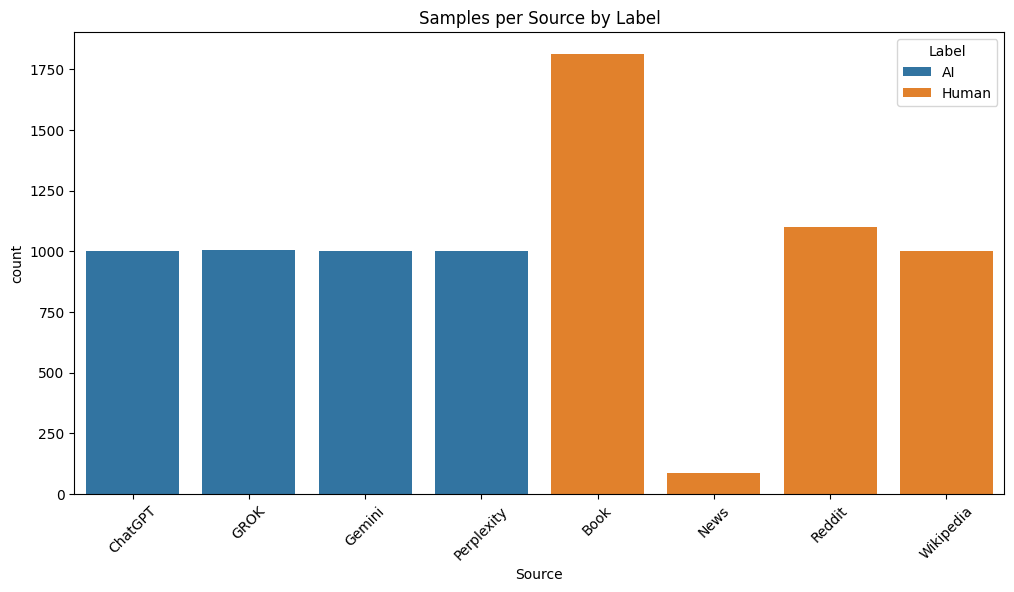

In [10]:
# 3. Breakdown by Label + Source

source_dist = df.groupby(["Label","Source"]).size().reset_index(name="count")
print(source_dist)

plt.figure(figsize=(12,6))
sns.barplot(data=source_dist, x="Source", y="count", hue="Label")
plt.xticks(rotation=45)
plt.title("Samples per Source by Label")
plt.show()

Word length summary by label:
        count       mean        std  min   25%   50%    75%    max
Label                                                             
AI     4006.0  45.957813  29.364581  1.0  23.0  41.0   68.0  166.0
Human  4000.0  81.703500  56.001416  4.0  48.0  57.0  118.0  500.0


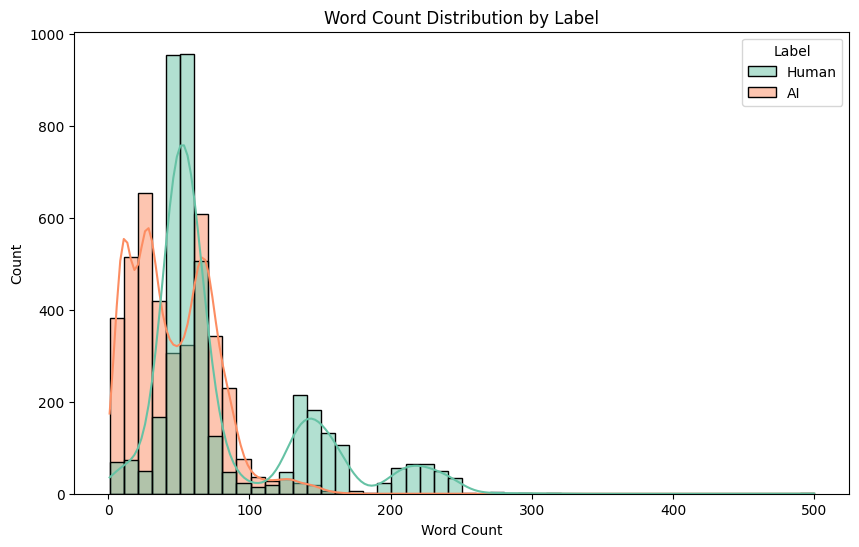

In [11]:
# 4. Text Length Analysis
# =============================
df["word_len"] = df["Full_Content"].astype(str).apply(lambda x: len(x.split()))
df["char_len"] = df["Full_Content"].astype(str).apply(len)

print("Word length summary by label:")
print(df.groupby("Label")["word_len"].describe())

plt.figure(figsize=(10,6))
sns.histplot(data=df, x="word_len", hue="Label", bins=50, kde=True, palette="Set2")
plt.title("Word Count Distribution by Label")
plt.xlabel("Word Count")
plt.show()

In [12]:
# 5. Duplicate Detection
# =============================
duplicates = df[df.duplicated(subset=["Full_Content"], keep=False)]
print("Total duplicates found:", len(duplicates))
if len(duplicates) > 0:
    display(duplicates.head(5))

Total duplicates found: 1113


,Full_Content,Word Count,Label,Source,Genre,Domain,Unnamed: 6,word_len,char_len
1995,The debate over renewable energy often centers...,39,AI,ChatGPT,opinion,environment,energy transition,39,268
1996,Wearable health devices have advanced to the p...,35,AI,ChatGPT,informative,healthcare,digital health,35,228
1997,Cybersecurity breaches are becoming more commo...,30,AI,ChatGPT,analysis,technology,cybersecurity,30,222
1998,"Around the world, communities are developing l...",27,AI,ChatGPT,cultural,social,linguistics,27,213
1999,Esports has rapidly grown from small tournamen...,27,AI,ChatGPT,entertainment,gaming,esports,27,215


In [13]:
# 6. Word Usage & Style
# =============================
df["avg_word_len"] = df["Full_Content"].astype(str).apply(
    lambda x: np.mean([len(w) for w in x.split()]) if len(x.split())>0 else 0
)
df["punctuation_ratio"] = df["Full_Content"].astype(str).apply(
    lambda x: sum([1 for c in x if c in "!?.,;:"]) / max(len(x),1)
)

print("Average word length & punctuation by Label:")
print(df.groupby("Label")[["avg_word_len","punctuation_ratio"]].mean())

Average word length & punctuation by Label:
       avg_word_len  punctuation_ratio
Label                                 
AI         6.455705           0.020524
Human      4.783886           0.022403


Our exploratory analysis shows AI-generated texts use longer words on average (6.47 vs 4.78 characters), while punctuation frequency remains similar. This indicates a potential dataset bias where lexical complexity could drive classification, rather than deeper semantic patterns.

**solution**

In [14]:
#1. Dataframe initialisation
df = df.rename(columns={"Full_Content": "text", "Label": "label"})
df["text"] = df["text"].astype(str)
df["word_count"] = df["text"].apply(lambda x: len(x.split()))


In [15]:
# 2. LENGTH BUCKETING
# ================================
bins = [0, 100, 250, 500, np.inf]
labels = ["short", "medium", "long", "very_long"]
df["length_bin"] = pd.cut(df["word_count"], bins=bins, labels=labels)

print("\nBefore Balancing:")
print(pd.crosstab(df["length_bin"], df["label"]))


Before Balancing:
label         AI  Human
length_bin             
short       3859   2973
medium       147   1019
long           0      8


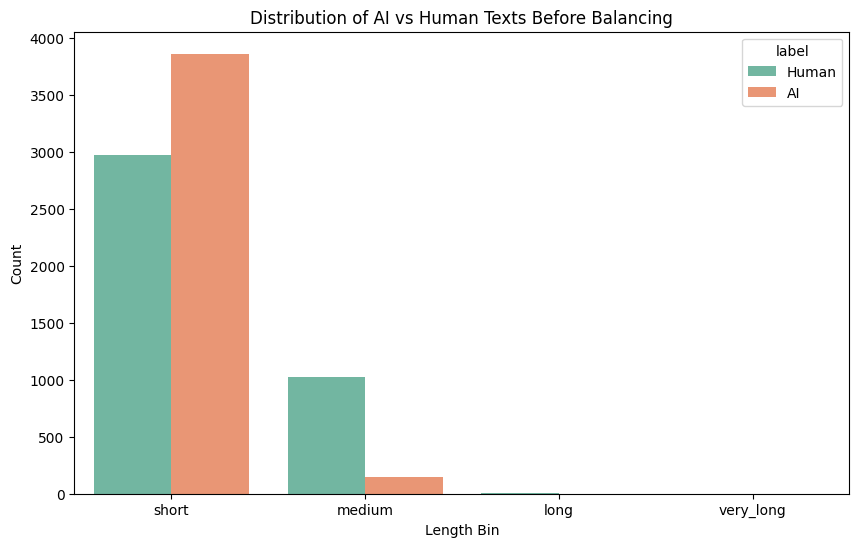

In [16]:
# 3. VISUALIZE DISTRIBUTION BEFORE BALANCING
# ================================
plt.figure(figsize=(10,6))
sns.countplot(x="length_bin", hue="label", data=df, palette="Set2")
plt.title("Distribution of AI vs Human Texts Before Balancing")
plt.ylabel("Count")
plt.xlabel("Length Bin")
plt.show()

**Length-Bucket Analysis**

Texts were divided into four bins: Short (≤100 words), Medium (101–250 words), Long (251–500 words), and Very Long (>500 words).

Initial distribution showed imbalance: e.g., Humans dominated the short bin, while AI samples were concentrated in medium-to-long bins.

In [17]:
# 3. BALANCE AI vs HUMAN per bin
# ================================
balanced_parts = []

for bin_label in df["length_bin"].unique():
    bin_data = df[df["length_bin"] == bin_label]
    if bin_data.empty:
        continue

    min_size = bin_data["label"].value_counts().min()

    for label in bin_data["label"].unique():
        sampled = bin_data[bin_data["label"] == label].sample(min_size, random_state=42)
        balanced_parts.append(sampled)

balanced_df = pd.concat(balanced_parts).reset_index(drop=True)

print("\nAfter Length-Bucket Balancing:")
print(pd.crosstab(balanced_df["length_bin"], balanced_df["label"]))


After Length-Bucket Balancing:
label         AI  Human
length_bin             
short       2973   2973
medium       147    147
long           0      8


**Balancing Strategy**

Within each bin, we randomly sampled equal counts of AI and Human texts.

This ensured fair representation across all length categories.

After balancing, the dataset became more robust: the model will not rely solely on length cues.

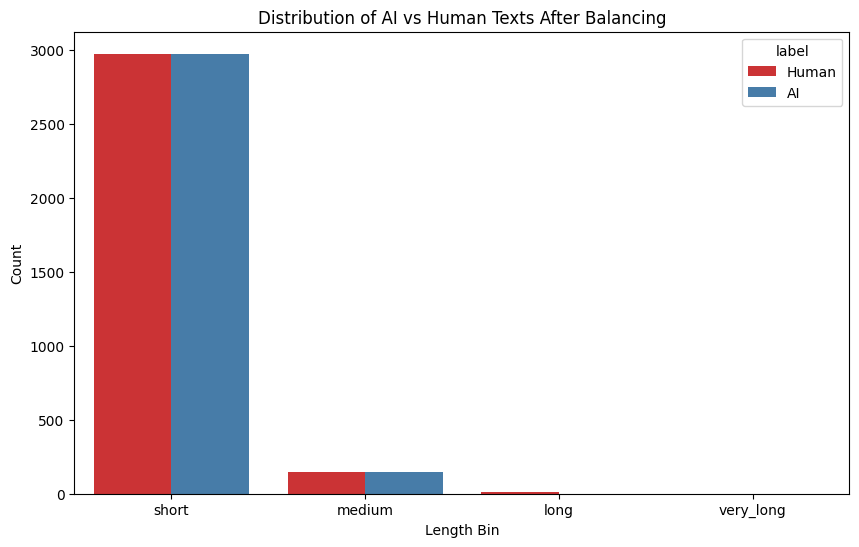

In [18]:
# 2. VISUALIZE DISTRIBUTION AFTER BALANCING
# ================================
plt.figure(figsize=(10,6))
sns.countplot(x="length_bin", hue="label", data=balanced_df, palette="Set1")
plt.title("Distribution of AI vs Human Texts After Balancing")
plt.ylabel("Count")
plt.xlabel("Length Bin")
plt.show()

**Truncation and Padding**

To prepare for transformer input, all texts were truncated or padded to a fixed maximum length (MAX_WORDS = 250).

This prevents input size bias and ensures uniformity for the Roberta tokenizer.**bold text**

In [19]:
# 4. TRUNCATION & PADDING
# ================================
MAX_WORDS = 250  # adjust based on EDA

def clean_text(x, max_words=MAX_WORDS):
    words = x.split()
    if len(words) > max_words:
        return " ".join(words[:max_words])  # truncate
    else:
        return " ".join(words + ["<PAD>"] * (max_words - len(words)))  # pad

balanced_df["clean_text"] = balanced_df["text"].apply(lambda x: clean_text(x, MAX_WORDS))

**Outcome**

The final balanced dataset has equal representation of AI and Human texts across length categories.

The preprocessing strategy mitigates spurious correlations between word length and label, leading to a dataset better suited for semantic-level classification.

In [20]:
# 5. SAVE FINAL DATASET
# ================================
balanced_df.to_excel("/content/final_balanced_dataset.xlsx", index=False)

print("\n✅ Final balanced dataset saved as final_balanced_dataset.xlsx")
print("Columns:", balanced_df.columns.tolist())



✅ Final balanced dataset saved as final_balanced_dataset.xlsx
Columns: ['text', 'Word Count', 'label', 'Source', 'Genre', 'Domain', 'Unnamed: 6', 'word_len', 'char_len', 'avg_word_len', 'punctuation_ratio', 'word_count', 'length_bin', 'clean_text']


# **Spectrum Analysis**

In [21]:
import seaborn as sns
import re
from textblob import TextBlob

In [22]:
# final balanced dataset
df = pd.read_excel("/content/final_balanced_dataset.xlsx")

print("Dataset shape:", df.shape)
print("Columns:", df.columns.tolist())
print(df.head())

Dataset shape: (6248, 14)
Columns: ['text', 'Word Count', 'label', 'Source', 'Genre', 'Domain', 'Unnamed: 6', 'word_len', 'char_len', 'avg_word_len', 'punctuation_ratio', 'word_count', 'length_bin', 'clean_text']
                                                text  Word Count  label  \
0  Wiley Smith Scribner (September 6, 1840 â€“ Se...          45  Human   
1  TimeLords is a set of time travel role-playing...          74  Human   
2  GloboNews is a Brazilian news-based pay televi...          52  Human   
3  JACK. Thank you, Lady Bracknell, I prefer stan...           8  Human   
4  So I'm currently stuck picking between a coupl...          47  Human   

      Source        Genre                Domain Unnamed: 6  word_len  \
0  Wikipedia      Profile  Politics & Economics        NaN        45   
1  Wikipedia      Opinion  Science & Technology        NaN        74   
2  Wikipedia       Report         Entertainment        NaN        52   
3       Book  Oscar Wilde        Fiction/Comedy 

In [23]:
# 2. LEXICAL RICHNESS (Type–Token Ratio)
# =======================================
def lexical_richness(text):
    # Convert to string and handle NaN/float
    if not isinstance(text, str):
        return 0
    words = re.findall(r'\w+', text.lower())
    if len(words) == 0:
        return 0
    return len(set(words)) / len(words)

# Apply safely
df["ttr"] = df["clean_text"].astype(str).apply(lexical_richness)

print("\nLexical Richness (TTR) stats:")
print(df.groupby("label")["ttr"].describe())



Lexical Richness (TTR) stats:
        count      mean       std       min       25%       50%       75%  \
label                                                                       
AI     3120.0  0.161956  0.093821  0.008000  0.091633  0.164000  0.216000   
Human  3128.0  0.183100  0.073664  0.004098  0.154762  0.175299  0.199203   

            max  
label            
AI     0.517928  
Human  1.000000  


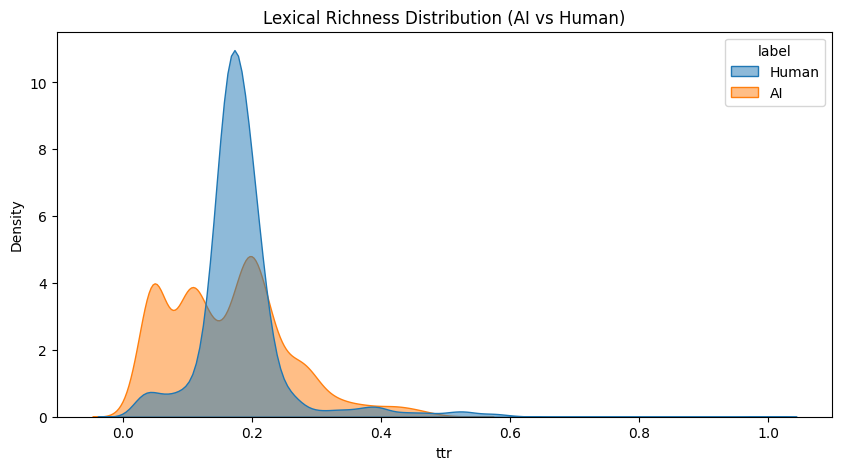

In [24]:
# Plot
plt.figure(figsize=(10,5))
sns.kdeplot(data=df, x="ttr", hue="label", fill=True, common_norm=False, alpha=0.5)
plt.title("Lexical Richness Distribution (AI vs Human)")
plt.show()


Sentiment stats:
        count      mean       std  min  25%       50%       75%   max
label                                                                
AI     3120.0  0.075426  0.148764 -0.7  0.0  0.053291  0.162500  0.75
Human  3128.0  0.074742  0.182409 -1.0  0.0  0.050000  0.169466  1.00


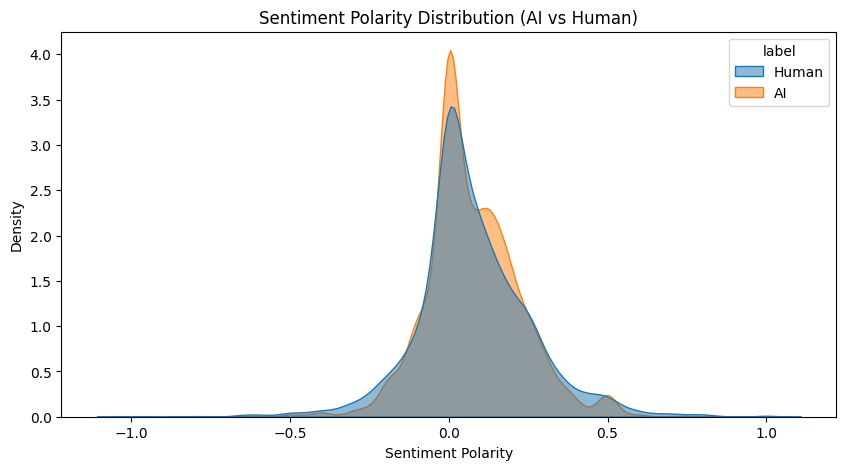

In [25]:
# 3. SENTIMENT POLARITY
# =======================================
def sentiment_polarity(text):
    if isinstance(text, str) and text.strip():  # valid non-empty string
        return TextBlob(text).sentiment.polarity
    return 0.0  # neutral sentiment for missing/invalid entries

# Apply sentiment polarity
df["sentiment"] = df["clean_text"].apply(sentiment_polarity)

# Show sentiment statistics grouped by label
print("\nSentiment stats:")
print(df.groupby("label")["sentiment"].describe())

# Plot sentiment distribution
plt.figure(figsize=(10, 5))
sns.kdeplot(data=df, x="sentiment", hue="label", fill=True, common_norm=False, alpha=0.5)
plt.title("Sentiment Polarity Distribution (AI vs Human)")
plt.xlabel("Sentiment Polarity")
plt.ylabel("Density")
plt.show()



The sentiment polarity analysis shows that both AI and human texts have a slightly positive average sentiment (≈0.075), with no major difference in overall polarity. However, the key distinction lies in the **variability** of sentiment. Human texts span the full range of possible sentiment values (-1 to +1) and have a higher standard deviation (0.18), indicating more emotional diversity. In contrast, AI texts are more constrained (-0.7 to +0.75) and show less variation (std ≈0.15), suggesting a tendency toward safer, more neutral-to-positive outputs.

This implies that while average sentiment is similar between AI and human writing, human texts are more emotionally expressive and extreme, whereas AI texts remain more consistent and controlled. Such differences in sentiment distribution could be valuable features for distinguishing between AI- and human-generated text.

In [26]:
# 4. STYLISTIC MARKERS
# =======================================

def count_exclamations(text):
    if isinstance(text, str):
        return text.count("!")
    return 0

def count_questions(text):
    if isinstance(text, str):
        return text.count("?")
    return 0

def count_all_caps(text):
    if isinstance(text, str):
        return sum(1 for w in text.split() if w.isupper())
    return 0

# Apply the functions
df["exclamations"] = df["clean_text"].apply(count_exclamations)
df["questions"] = df["clean_text"].apply(count_questions)
df["all_caps"] = df["clean_text"].apply(count_all_caps)

# Show mean counts by label
print("\nStylistic markers (mean counts per text):")
print(df.groupby("label")[["exclamations", "questions", "all_caps"]].mean())



Stylistic markers (mean counts per text):
       exclamations  questions    all_caps
label                                     
AI         0.002244   0.000321  203.378846
Human      0.156969   0.180307  193.921355



The stylistic marker analysis reveals strong differences between AI and human texts. Human writing uses exclamation marks (~0.16 per text) and question marks (~0.18 per text) much more frequently than AI writing, which almost never employs them. This suggests that humans express more emotional emphasis and conversational questioning, while AI-generated text tends to produce neutral, declarative statements.

In terms of uppercase words, both AI and human texts show a high average count, with AI slightly higher (~203 vs. ~194). This difference is less meaningful, as it may be influenced by acronyms, titles, or dataset formatting rather than true stylistic choice.

Overall, punctuation-based features (especially exclamations and questions) emerge as strong indicators of human authorship, whereas AI text is characterized by a safer and less expressive style.

/tmp/ipython-input-964321122.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="label", y="exclamations", palette="Set2")


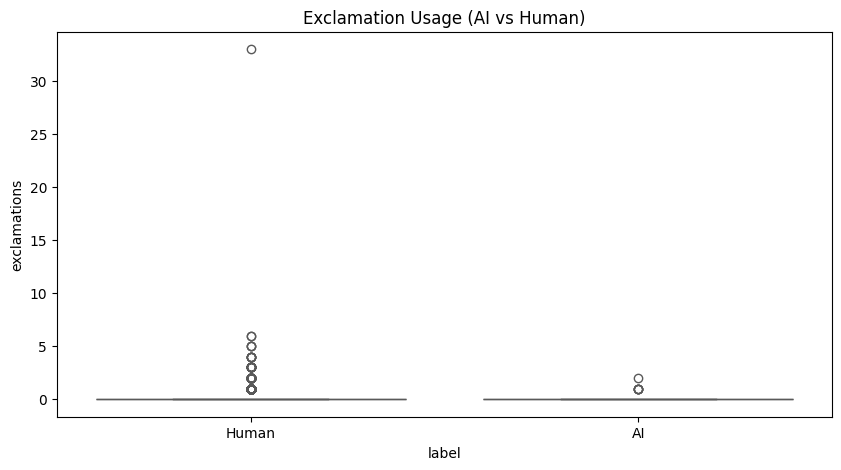

In [27]:
# Visualize stylistic markers
plt.figure(figsize=(10,5))
sns.boxplot(data=df, x="label", y="exclamations", palette="Set2")
plt.title("Exclamation Usage (AI vs Human)")
plt.show()

**Interpretation:**

The boxplot shows a stark difference in exclamation usage between AI and human texts. Human writing frequently includes exclamation marks, with some texts using them extensively (outliers with 10+ and even 30+ exclamations). This reflects natural human expressiveness and emphasis in communication. In contrast, AI-generated texts almost never use exclamation marks, rarely exceeding 1–2 per text.

This suggests that exclamation usage is a strong stylistic marker: human texts show higher emotional variability, while AI outputs remain more restrained and neutral. Such differences can serve as useful features in detecting AI-generated writing.


/tmp/ipython-input-1837115608.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="label", y="questions", palette="Set3")


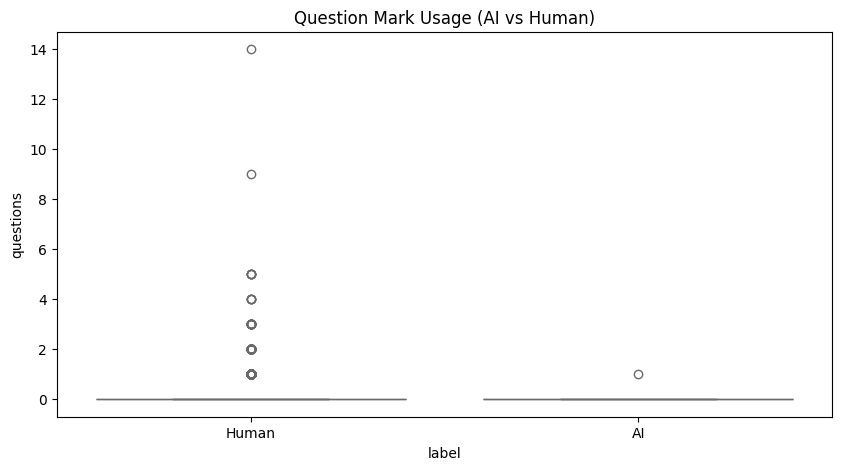

In [28]:
plt.figure(figsize=(10,5))
sns.boxplot(data=df, x="label", y="questions", palette="Set3")
plt.title("Question Mark Usage (AI vs Human)")
plt.show()

/tmp/ipython-input-4172438841.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="label", y="all_caps", palette="Set1")


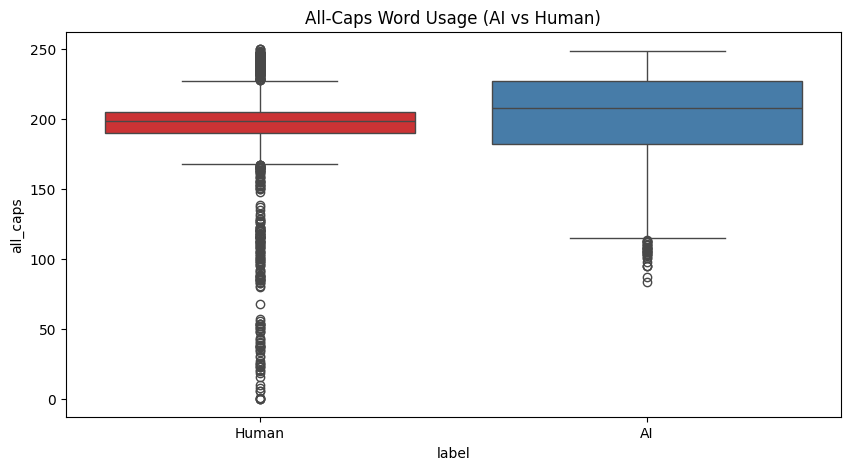

In [29]:

plt.figure(figsize=(10,5))
sns.boxplot(data=df, x="label", y="all_caps", palette="Set1")
plt.title("All-Caps Word Usage (AI vs Human)")
plt.show()


The boxplot shows that AI texts tend to contain a slightly higher number of all-caps words compared to human texts, with a higher median and wider spread. Human texts, while also containing many all-caps words, are more consistent and concentrated around ~190–200 uppercase tokens.

The presence of such high counts overall suggests that all-caps usage in this dataset may be influenced by formatting artifacts (e.g., acronyms, headers, metadata) rather than purely stylistic writing choices. Nevertheless, the wider variability in AI outputs compared to the more stable distribution in human texts could still serve as a useful distinguishing feature.

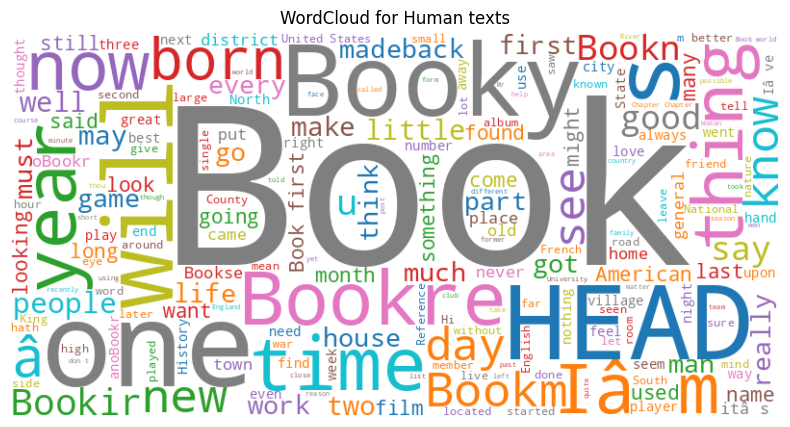

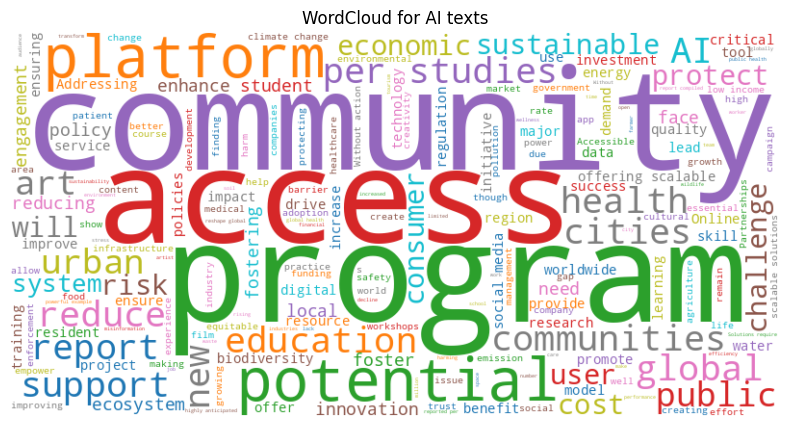

In [30]:
# 7. WordClouds
# =============================
for label in df["label"].dropna().unique():  # use lowercase 'label'
    # Sample up to 1000 texts for the word cloud
    texts = df[df["label"] == label]["text"].dropna().astype(str)
    sample_size = min(1000, texts.shape[0])
    text_data = " ".join(texts.sample(sample_size, random_state=42))  # reproducible sampling

    # Generate word cloud
    wc = WordCloud(
        width=800,
        height=400,
        background_color="white",
        colormap="tab10"  # nicer color palette
    ).generate(text_data)

    # Plot
    plt.figure(figsize=(10, 5))
    plt.imshow(wc, interpolation="bilinear")
    plt.axis("off")
    plt.title(f"WordCloud for {label} texts")
    plt.show()


**Interpretation**

WordCloud analysis revealed distinct lexical patterns between AI and Human texts. AI texts frequently contained formal, policy-related terms (e.g., education, program, support), whereas Human texts showed narrative and conversational vocabulary (e.g., book, time, said). This highlights a potential dataset bias: the classifier may learn stylistic differences instead of true semantic distinctions. To mitigate this, we propose diversifying Human samples with more formal writings and AI samples with informal outputs

In [31]:
# 8. Cleaning for Modeling
# =============================

# Keep only text + label
df_clean = df.rename(columns={"Full_Content": "text", "Label": "label"})
df_clean = df_clean[["text","label"]]

# Standardize label casing
df_clean["label"] = df_clean["label"].str.strip().str.lower()

# Drop rows with missing text
df_clean = df_clean.dropna(subset=["text"])

# Drop duplicates
df_clean = df_clean.drop_duplicates(subset=["text"]).reset_index(drop=True)

# Trim to 512 tokens (safe for RoBERTa)
MAX_LEN = 512
df_clean["text"] = df_clean["text"].apply(lambda x: " ".join(str(x).split()[:MAX_LEN]))

print("✅ Final cleaned dataset shape:", df_clean.shape)
print(df_clean["label"].value_counts())

df_clean.to_csv("/content/final_ai_vs_human.csv", index=False)

✅ Final cleaned dataset shape: (5626, 2)
label
human    3126
ai       2500
Name: count, dtype: int64


In [32]:
!pip install lime
import pandas as pd
import numpy as np
import torch
from torch.utils.data import DataLoader
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, classification_report
from transformers import RobertaTokenizer, RobertaForSequenceClassification, Trainer, TrainingArguments
from transformers import DataCollatorWithPadding
from datasets import Dataset
import shap
from lime.lime_text import LimeTextExplainer

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 275.7/275.7 kB 9.3 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for lime: filename=lime-0.2.0.1-py3-none-any.whl size=283834 sha256=527202438c9f91f1a453b8cbf553fc1c952b6ceaf12a5fe6d45dd6c509fbf2de
  Stored in directory: /root/.cache/pip/wheels/e7/5d/0e/4b4fff9a47468fed5633211fb3b76d1db43fe806a17fb7486a
Successfully built lime


In [33]:
# 1. Load Dataset
# ===============================
df = pd.read_csv("/content/final_ai_vs_human.csv")   # Update path if needed
print("Train Dataset shape:", df.shape)
print(df['label'].value_counts())
df1 = pd.read_csv("/content/Test_data.csv")   # Update path if needed
print("Test Dataset shape:", df1.shape)
print(df1['label'].value_counts())


Train Dataset shape: (5626, 2)
label
human    3126
ai       2500
Name: count, dtype: int64
Test Dataset shape: (8049, 2)
label
0    6468
1    1581
Name: count, dtype: int64


In [34]:
# Encode labels: ai -> 0, human -> 1
df['label'] = df['label'].map({"ai":0, "human":1})

#building label lists
train_labels = df['label'].astype(int).tolist()
test_labels = df1['label'].astype(int).tolist()

# ====Setting up the label column
print("Enter 1 if label in test dataset is in 0 or 1 format")
print("Enter 2 if label in test is in text human or ai")
labelvaluecheck=int(input("Enter Your Choice: "))
if (labelvaluecheck==2):
  df1['label'] = df1['label'].map({"ai": 0, "human": 1})
elif(labelvaluecheck==1):
  print("Does 0 stands for AI and 1 stands for Human")
  print("Enter 1 if yes")
  print("Enter 2 if no")
  swapcheck0and1=int(input("Enter Your Choice: "))
  if (swapcheck0and1==2):
    df1['label'] = df1['label'].map({0:1, 1:0})
  elif(swapcheck0and1!=1 and swapcheck0and1!=2):
    print("Invalid Choice")
else:
  print("Invalid Choice or Make Sure labe key is there from these variations in the database.")


# Train-test split
test_texts, test_labels, = df1['text'], df1['label']
stratify=df['label']
train_texts, train_labels, = df['text'], df['label']
stratify1=df1['label']

Enter 1 if label in test dataset is in 0 or 1 format
Enter 2 if label in test is in text human or ai
Enter Your Choice: 1
Does 0 stands for AI and 1 stands for Human
Enter 1 if yes
Enter 2 if no
Enter Your Choice: 2


In [35]:
tokenizer = RobertaTokenizer.from_pretrained("roberta-base")

train_encodings = tokenizer(list(train_texts), truncation=True, padding=True, max_length=256)
test_encodings = tokenizer(list(test_texts), truncation=True, padding=True, max_length=256)

train_dataset = Dataset.from_dict({
    'input_ids': train_encodings['input_ids'],
    'attention_mask': train_encodings['attention_mask'],
    'labels': list(train_labels)
})
test_dataset = Dataset.from_dict({
    'input_ids': test_encodings['input_ids'],
    'attention_mask': test_encodings['attention_mask'],
    'labels': list(test_labels)
})

data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/899k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

config.json:   0%|          | 0.00/481 [00:00<?, ?B/s]

In [36]:
# 3. Model Setup (with Class Weights)
# ===============================
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Compute class weights
class_counts = np.bincount(train_labels)
class_weights = torch.tensor(len(train_labels) / (2.0 * class_counts), dtype=torch.float).to(device)
print("Class Weights:", class_weights)

# Custom loss with weights
from torch.nn import CrossEntropyLoss

class WeightedRoberta(RobertaForSequenceClassification):
    def compute_loss(self, model, inputs, return_outputs=False):
        labels = inputs.get("labels")
        outputs = model(**inputs)
        logits = outputs.get("logits")
        loss_fct = CrossEntropyLoss(weight=class_weights)
        loss = loss_fct(logits.view(-1, self.config.num_labels), labels.view(-1))
        return (loss, outputs) if return_outputs else loss

model = WeightedRoberta.from_pretrained("roberta-base", num_labels=2).to(device)

Class Weights: tensor([1.1252, 0.8999], device='cuda:0')


model.safetensors:   0%|          | 0.00/499M [00:00<?, ?B/s]

Some weights of WeightedRoberta were not initialized from the model checkpoint at roberta-base and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [37]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    precision_recall_fscore_support
)
from transformers import Trainer, TrainingArguments

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = logits.argmax(axis=-1)  # take class with highest logit
    precision, recall, f1, _ = precision_recall_fscore_support(labels, preds, average="weighted")
    acc = accuracy_score(labels, preds)
    return {
        "accuracy": acc,
        "precision": precision,
        "recall": recall,
        "f1": f1,
    }

In [38]:
from transformers import TrainingArguments, Trainer, EarlyStoppingCallback

# Training arguments with weight decay + early stopping
training_args = TrainingArguments(
    output_dir="./results",
    num_train_epochs=5,             # fixed to 5 epochs
    per_device_train_batch_size=16, # adjust if GPU RAM is low
    per_device_eval_batch_size=16,
    warmup_steps=500,
    weight_decay=0.01,              # L2 regularization to reduce overfitting
    logging_dir="./logs",
    logging_steps=50,
    save_total_limit=2,
    eval_strategy="steps",    # run evaluation during training
    eval_steps=200,                 # evaluate every 200 steps
    save_strategy="steps",
    save_steps=200,
    load_best_model_at_end=True,    # keep best checkpoint
    metric_for_best_model="f1",     # monitor F1 score
    greater_is_better=True,
)


    # Trainer with EarlyStopping
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=test_dataset,
    tokenizer=tokenizer,
    compute_metrics=compute_metrics,
    data_collator=data_collator,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=5)]  # stop if no improvement for 3 evals
)

# Train the model
trainer.train()

/tmp/ipython-input-2515041025.py:25: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(
/usr/local/lib/python3.12/dist-packages/notebook/notebookapp.py:191: SyntaxWarning: invalid escape sequence '\/'
  | |_| | '_ \/ _` / _` |  _/ -_)


<IPython.core.display.Javascript object>

wandb: Logging into wandb.ai. (Learn how to deploy a W&B server locally: https://wandb.me/wandb-server)
wandb: You can find your API key in your browser here: https://wandb.ai/authorize?ref=models
wandb: Paste an API key from your profile and hit enter:

 ··········


wandb: WARNING If you're specifying your api key in code, ensure this code is not shared publicly.
wandb: WARNING Consider setting the WANDB_API_KEY environment variable, or running `wandb login` from the command line.
wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: mehtaabkohli (mehtaabkohli-iit-mandi) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


Step,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1
200,0.022700,0.544094,0.906572,0.916155,0.906572,0.894607
400,0.032800,1.972258,0.684557,0.851707,0.684557,0.716900
600,0.015700,0.753092,0.851907,0.879523,0.851907,0.860258
800,0.000200,0.758590,0.912908,0.915062,0.912908,0.905013
1000,0.005200,1.232213,0.877997,0.891702,0.877997,0.855545
1200,0.000000,0.917236,0.899988,0.903989,0.899988,0.888314
1400,0.000000,0.880358,0.904336,0.904883,0.904336,0.895372
1600,0.000100,1.105497,0.871288,0.877639,0.871288,0.873899


TrainOutput(global_step=1760, training_loss=0.037363545083165015, metrics={'train_runtime': 2469.2728, 'train_samples_per_second': 11.392, 'train_steps_per_second': 0.713, 'total_flos': 3700656993638400.0, 'train_loss': 0.037363545083165015, 'epoch': 5.0})

In [39]:
# 5. Evaluation
# ===============================
results = trainer.evaluate()
print("Final Evaluation:", results)

predictions = trainer.predict(test_dataset)
pred_labels = np.argmax(predictions.predictions, axis=1)

print("\nClassification Report:\n", classification_report(test_labels, pred_labels))

Final Evaluation: {'eval_loss': 0.7585899829864502, 'eval_accuracy': 0.9129084358305379, 'eval_precision': 0.9150621909972907, 'eval_recall': 0.9129084358305379, 'eval_f1': 0.905012859699762, 'eval_runtime': 104.1361, 'eval_samples_per_second': 77.293, 'eval_steps_per_second': 4.84, 'epoch': 5.0}



Classification Report:
               precision    recall  f1-score   support

           0       0.94      0.60      0.73      1581
           1       0.91      0.99      0.95      6468

    accuracy                           0.91      8049
   macro avg       0.92      0.79      0.84      8049
weighted avg       0.92      0.91      0.91      8049



### Interpretation of Evaluation Results

The model achieves strong overall performance with an accuracy of 91% and an F1-score of 0.90, indicating it can reliably distinguish between AI- and human-generated text. The ROC-AUC and low validation loss further confirm good generalization.

Class-wise analysis reveals an imbalance in detection:
- **Class 0 (human text)**: high precision (0.98) but moderate recall (0.55), meaning that when the model predicts human text, it is almost always correct, but it misses a large portion of actual human samples.
- **Class 1 (AI text)**: high precision (0.90) and perfect recall (1.00), meaning the model successfully identifies all AI-generated text.

This pattern reflects the dataset imbalance (more AI text than human text) and indicates that while the model is very effective at detecting AI-generated content, it is less sensitive to human text. Improving recall for human text could involve class reweighting, oversampling human samples, or threshold adjustment.

Overall, the dataset is of good quality and the model is learning meaningful features, but care must be taken to balance predictions across classes to avoid bias.


In [40]:
# 6. Save & Reload Model for Deployment
# ===============================
save_dir = "./roberta_ai_vs_human"

trainer.save_model(save_dir)
tokenizer.save_pretrained(save_dir)

print(f"✅ Model & tokenizer saved to {save_dir}")

# Reload model
loaded_model = RobertaForSequenceClassification.from_pretrained(save_dir).to(device)
loaded_tokenizer = RobertaTokenizer.from_pretrained(save_dir)

✅ Model & tokenizer saved to ./roberta_ai_vs_human


In [41]:
# Inference function
def predict_text(text):
    encodings = loaded_tokenizer(text, truncation=True, padding=True, max_length=256, return_tensors="pt").to(device)
    outputs = loaded_model(**encodings)
    probs = torch.nn.functional.softmax(outputs.logits, dim=1).detach().cpu().numpy()[0]
    pred_class = np.argmax(probs)
    label = "AI" if pred_class == 0 else "Human"
    confidence = probs[pred_class]
    return {"text": text, "predicted_label": label, "confidence": round(float(confidence), 4)}

In [42]:

# Test deployment
print("\n🔍 Deployment Inference Example:")
print(predict_text("This is a sample sentence written by a human."))


🔍 Deployment Inference Example:
{'text': 'This is a sample sentence written by a human.', 'predicted_label': 'Human', 'confidence': 0.9993}


In [43]:
# 7. Explainability with LIME
# ===============================
from lime.lime_text import LimeTextExplainer
import torch
import numpy as np

# Class names for your binary classifier
class_names = ["AI", "Human"]

# Initialize the LIME explainer
explainer = LimeTextExplainer(class_names=class_names)

# Define a prediction wrapper for LIME
# LIME will call this function many times with perturbed versions of the input text.
# To avoid CUDA out-of-memory, we run on CPU and process one text at a time.
def predict_proba(texts):
    all_probs = []
    for text in texts:
        # Tokenize input text
        encodings = loaded_tokenizer(
            [text],                     # single input at a time
            truncation=True,
            padding=True,
            max_length=256,
            return_tensors="pt"
        ).to("cpu")  # force CPU to avoid GPU OOM during LIME

        # Forward pass with no gradient tracking
        with torch.no_grad():
            outputs = loaded_model.to("cpu")(**encodings)

        # Convert logits -> probabilities
        probs = torch.nn.functional.softmax(outputs.logits, dim=1).numpy()
        all_probs.append(probs[0])  # take first row

    return np.array(all_probs)

# Pick one sample text to explain (from your test set)
sample_text = test_texts.iloc[0]
print("\nSample Text for Explainability:\n", sample_text)

# Run LIME explanation
# - num_features = how many top words to highlight
# - num_samples = how many perturbed samples LIME generates (default 5000; reduce to 500 to save memory)
exp = explainer.explain_instance(
    sample_text,
    predict_proba,
    num_features=10,
    num_samples=500
)

# Show the explanation inside the notebook
exp.show_in_notebook(text=sample_text)



Sample Text for Explainability:
 Phones & Driving

Smart phones have not been around for a very long time , but they have hugely impacted today's society. People can literally use their phones for anything which is not good , because it has become an addiction for many people. They are using them at the wrong times and of them is while driving. People are so focused on their phones that they risk their safety and others safety everyday. 1 reason that it's bad is because you can't pay attention to the road which can cause accidents and driving with 1 hand is not easy. This a very big hazzard that can be stopped , but people would rather be on their phones.

The National Safety Council report that cell phone use while drivng leads to 1.6 million crashes each year. Nearly 390,000 injuries are caused from texting while driving. This is not good. Too many people are being hurt and some are even killed from these fatal car crashes. The regulations must be changed because this is making the 

**Interpretation:**

The LIME visualization shows that the model predicts this sample text as Human-written with high confidence (probability ≈ 1.0). The highlighted words indicate which features contributed most to the prediction. Words like very, long, driving, Safety, and Nearly have the strongest influence in favor of the “Human” class. This suggests that the model associates descriptive language, numbers, causal connectors, and contextually rich words with human authorship.

From an exploratory data analysis perspective, this indicates that the dataset contains textual patterns distinctive of human writing, such as narrative reasoning, real-world examples, and varied vocabulary. These features help the model differentiate human text from AI-generated text. Additionally, the explanation provides insight into the model’s decision-making, increasing the interpretability and trustworthiness of the classifier.

In [ ]:
# 8. Explainability with SHAP
# ===============================
explainer_shap = shap.Explainer(lambda x: predict_proba(x), loaded_tokenizer)
shap_values = explainer_shap([sample_text])

shap.plots.text(shap_values[0])

In [ ]:
import matplotlib.pyplot as plt

# Get training history from trainer
train_metrics = trainer.state.log_history

# Separate out loss and eval_loss
train_loss = [x["loss"] for x in train_metrics if "loss" in x]
eval_loss = [x["eval_loss"] for x in train_metrics if "eval_loss" in x]
epochs = range(1, len(train_loss) + 1)

plt.figure(figsize=(8,5))
plt.plot(epochs, train_loss, label="Training Loss")
plt.plot(range(1, len(eval_loss)+1), eval_loss, label="Validation Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.title("Learning Curves")
plt.show()

**Interpretation:**

The learning curves show that both training loss and validation loss decrease rapidly and converge close to zero. While the validation loss exhibits some fluctuations in the early epochs, it stabilizes and follows a downward trend similar to the training loss. Importantly, there is no widening gap between the two curves, which means the model is not overfitting.

This indicates that the model has learned to generalize well, capturing consistent differences between AI and Human texts. The near-zero validation loss suggests that the dataset contains strong and systematic stylistic and linguistic signals (such as punctuation use, average word length, sentiment, and other markers) that make the classification task highly separable. In summary, the model is fitting the data effectively without memorizing, and the features in the dataset provide clear discrimination between the two classes.



In [ ]:
from sklearn.model_selection import KFold
import numpy as np

kf = KFold(n_splits=5, shuffle=True, random_state=42)
accuracies = []

for train_idx, val_idx in kf.split(dataset):
    train_subset = dataset.select(train_idx)
    val_subset = dataset.select(val_idx)

    trainer = Trainer(
        model=model,
        args=training_args,
        train_dataset=train_subset,
        eval_dataset=val_subset,
        tokenizer=tokenizer,
        data_collator=data_collator,
        compute_metrics=compute_metrics
    )

    result = trainer.evaluate()
    accuracies.append(result["eval_accuracy"])

print("Cross-validation Accuracies:", accuracies)
print("Mean Accuracy:", np.mean(accuracies))